# EGFR pIC50 — EDA & Chemical Space

**Dataset:** `CHEMBL203` curated IC50 → pIC50 (10,502 molecules after curation)  
**Goal:** Understand the distribution of activity, molecular properties, and chemical diversity before modelling.

## Sections
1. Dataset overview
2. pIC50 distribution & activity class split
3. Molecular descriptor distributions (RDKit)
4. Lipinski Rule of Five compliance
5. Chemical space — UMAP of Morgan fingerprints
6. Scaffold diversity (Murcko)
7. pIC50 vs descriptor correlations

In [52]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import PandasTools
PandasTools.RenderImagesInAllDataFrames(images=True)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

## 1. Load data

In [53]:
parquet_path = Path('../data/processed/CHEMBL203_curated.parquet')
csv_path     = Path('../data/curated_dataset.csv')

if parquet_path.exists():
    df = pd.read_parquet(parquet_path)
    df = df.rename(columns={'pic50': 'pIC50', 'canonical_smiles': 'smiles'})
else:
    df = pd.read_csv(csv_path, index_col=0)

print(f"Loaded {len(df):,} records — columns: {df.columns.tolist()}")
df.head()

Loaded 10,502 records — columns: ['molecule_chembl_id', 'smiles', 'IC50', 'pIC50']


,molecule_chembl_id,smiles,IC50,pIC50
0,CHEMBL10,C[S+]([O-])c1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccncc...,53000.0,4.51
1,CHEMBL12131,Cc1cc(C(C#N)c2ccc(Cl)cc2)c(Cl)cc1NC(=O)c1cc(I)...,564.0,6.25
2,CHEMBL13485,CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\C(=O)Nc3ccc(C...,3000.0,5.52
3,CHEMBL13629,CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\C(=O)Nc3ccc(B...,10000.0,5.00
4,CHEMBL104,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,69421.0,4.16


## 2. Dataset overview

In [54]:
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\npIC50 summary:")
df['pIC50'].describe().round(3)

Shape: (10502, 4)

Missing values:
molecule_chembl_id    0
smiles                0
IC50                  0
pIC50                 0
dtype: int64

pIC50 summary:


count    10502.000
mean         6.953
std          1.353
min          2.190
25%          6.000
50%          7.060
75%          7.999
max         11.520
Name: pIC50, dtype: float64

## 3. pIC50 distribution & activity class split

A common threshold for EGFR: **pIC50 ≥ 6** (IC50 ≤ 1 µM) = active, **< 6** = inactive.  
This threshold matters for scaffold-split class balance checks before model training.

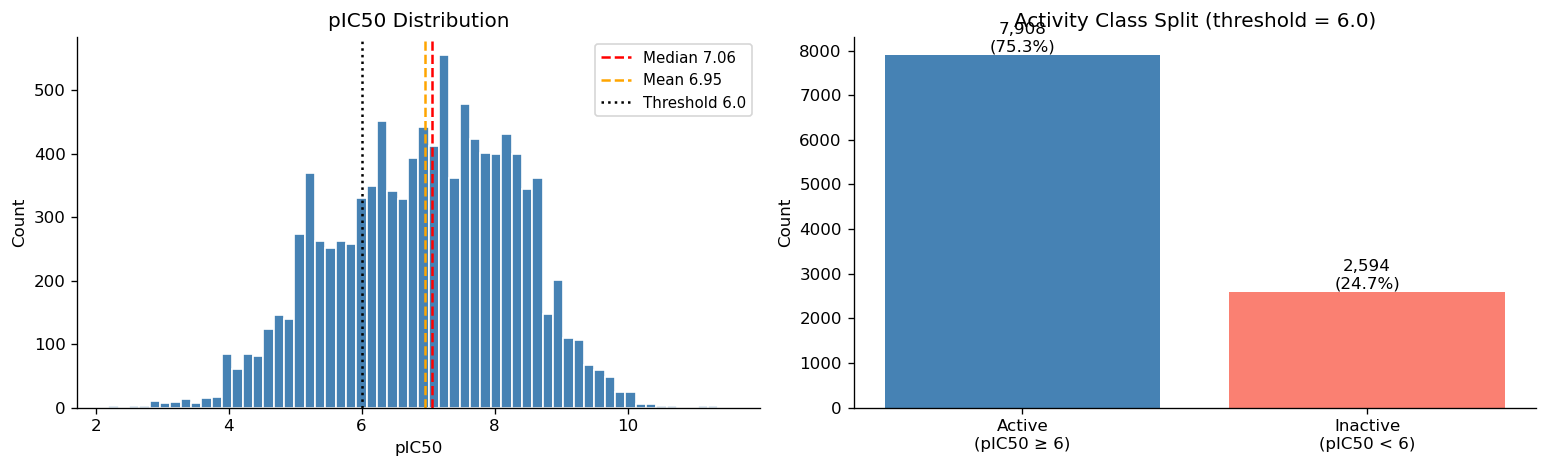

Active   (pIC50 >= 6.0): 7,908  (75.3%)
Inactive (pIC50 <  6.0): 2,594  (24.7%)


In [55]:
ACTIVITY_THRESHOLD = 6.0

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- histogram ---
axes[0].hist(df['pIC50'], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(df['pIC50'].median(), color='red',    linestyle='--', lw=1.5,
                label=f'Median {df["pIC50"].median():.2f}')
axes[0].axvline(df['pIC50'].mean(),   color='orange', linestyle='--', lw=1.5,
                label=f'Mean {df["pIC50"].mean():.2f}')
axes[0].axvline(ACTIVITY_THRESHOLD,   color='black',  linestyle=':',  lw=1.5,
                label=f'Threshold {ACTIVITY_THRESHOLD}')
axes[0].set_xlabel('pIC50')
axes[0].set_ylabel('Count')
axes[0].set_title('pIC50 Distribution')
axes[0].legend(fontsize=9)

# --- activity class bar ---
n_active   = (df['pIC50'] >= ACTIVITY_THRESHOLD).sum()
n_inactive = len(df) - n_active
bars = axes[1].bar(['Active\n(pIC50 ≥ 6)', 'Inactive\n(pIC50 < 6)'],
                   [n_active, n_inactive], color=['steelblue', 'salmon'])
for bar, count in zip(bars, [n_active, n_inactive]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80,
                 f'{count:,}\n({count/len(df)*100:.1f}%)', ha='center', fontsize=10)
axes[1].set_ylabel('Count')
axes[1].set_title(f'Activity Class Split (threshold = {ACTIVITY_THRESHOLD})')

plt.tight_layout()
plt.show()

print(f"Active   (pIC50 >= {ACTIVITY_THRESHOLD}): {n_active:,}  ({n_active/len(df)*100:.1f}%)")
print(f"Inactive (pIC50 <  {ACTIVITY_THRESHOLD}): {n_inactive:,}  ({n_inactive/len(df)*100:.1f}%)")

## 4. Molecular descriptors

Computing eight core RDKit descriptors used in Lipinski-style drug-likeness analysis.

In [56]:
def compute_descriptors(smiles: str) -> dict | None:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        'MW':       Descriptors.MolWt(mol),
        'LogP':     Descriptors.MolLogP(mol),
        'HBD':      rdMolDescriptors.CalcNumHBD(mol),
        'HBA':      rdMolDescriptors.CalcNumHBA(mol),
        'TPSA':     rdMolDescriptors.CalcTPSA(mol),
        'RotBonds': rdMolDescriptors.CalcNumRotatableBonds(mol),
        'Rings':    rdMolDescriptors.CalcNumRings(mol),
        'ArRings':  rdMolDescriptors.CalcNumAromaticRings(mol),
    }

desc_df = pd.DataFrame(df['smiles'].apply(compute_descriptors).tolist())
df_full = pd.concat([df.reset_index(drop=True), desc_df], axis=1)
print(f"Descriptors computed for {desc_df.notna().all(axis=1).sum():,} / {len(df):,} molecules")
desc_df.describe().round(2)

Descriptors computed for 10,502 / 10,502 molecules


,MW,LogP,HBD,HBA,TPSA,RotBonds,Rings,ArRings
count,10502.00,10502.00,10502.00,10502.00,10502.00,10502.00,10502.00,10502.00
mean,482.24,4.58,2.19,6.73,96.10,6.91,4.43,3.55
std,121.02,1.44,1.19,2.18,30.55,3.21,1.31,0.94
min,110.11,-1.98,0.00,0.00,3.88,0.00,0.00,0.00
25%,402.45,3.67,1.00,5.00,76.80,5.00,4.00,3.00
50%,481.61,4.53,2.00,7.00,96.27,7.00,4.00,4.00
75%,555.09,5.48,3.00,8.00,111.71,9.00,5.00,4.00
max,1425.80,13.03,17.00,19.00,530.87,36.00,12.00,10.00


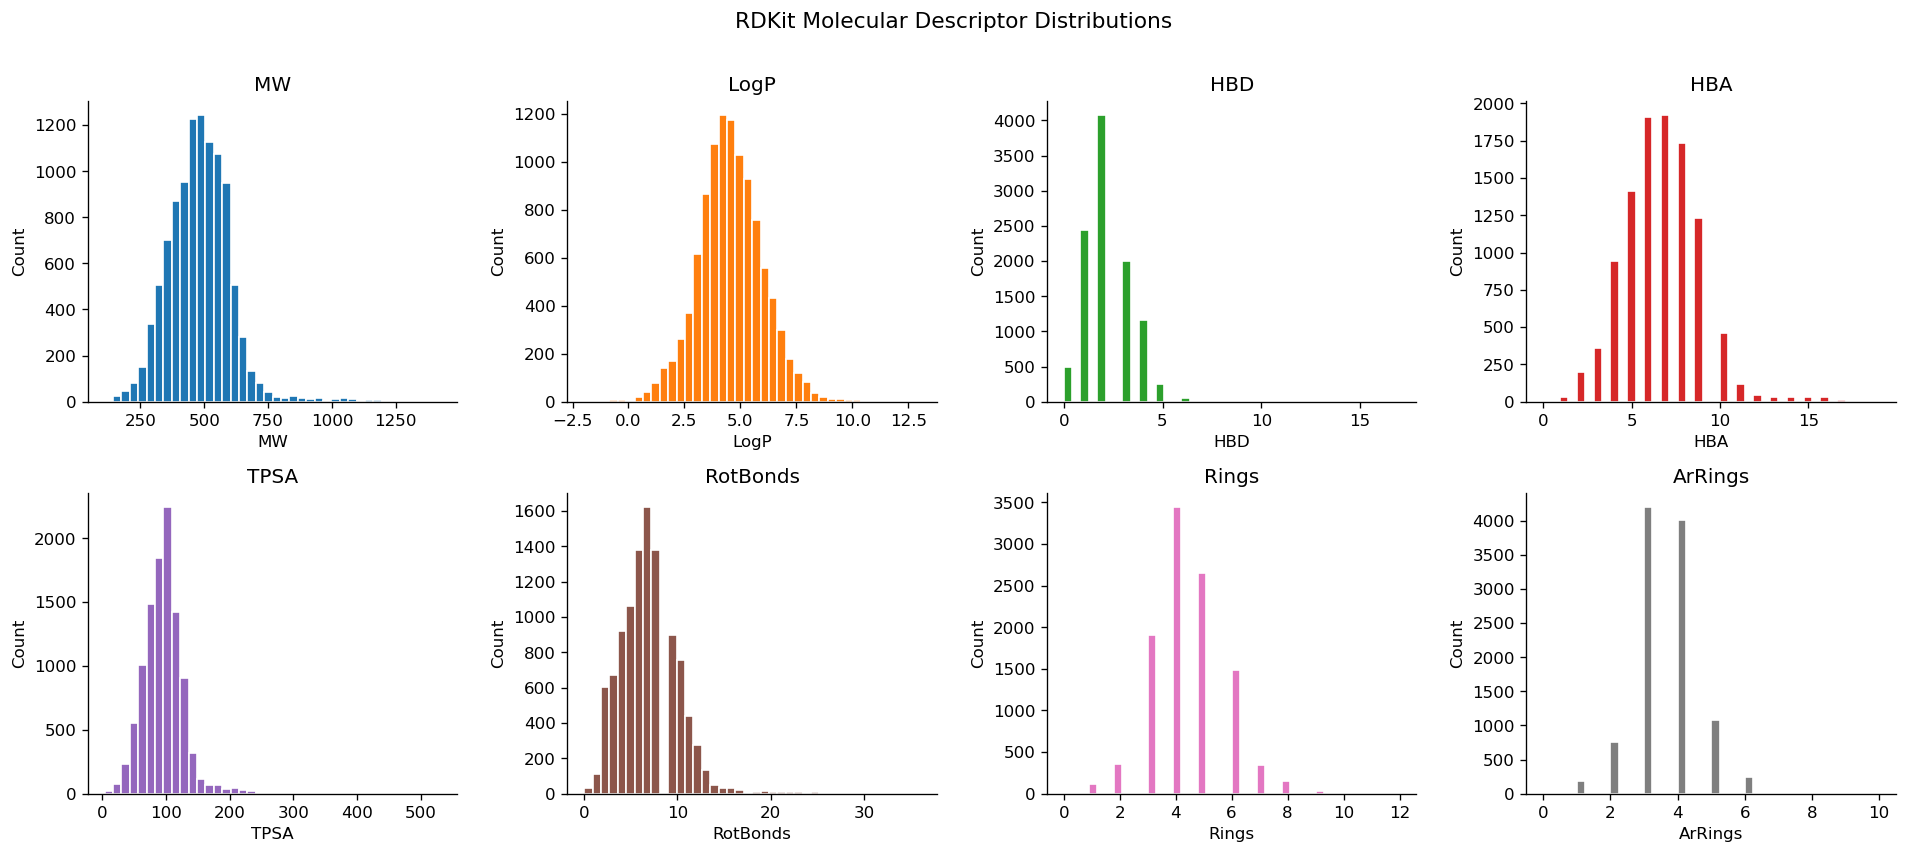

In [57]:
descriptors = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotBonds', 'Rings', 'ArRings']
colors = sns.color_palette('tab10', len(descriptors))

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col, color in zip(axes.flat, descriptors, colors):
    ax.hist(df_full[col].dropna(), bins=40, color=color, edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.suptitle('RDKit Molecular Descriptor Distributions', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 5. Lipinski Rule of Five compliance

Oral bioavailability heuristic: MW ≤ 500, LogP ≤ 5, HBD ≤ 5, HBA ≤ 10.  
EGFR inhibitors (especially 3rd-gen covalent ones like osimertinib) sometimes breach MW/LogP.

Rule              Pass       %
------------------------------
MW ≤ 500          5961   56.8%
LogP ≤ 5          6641   63.2%
HBD ≤ 5          10424   99.3%
HBA ≤ 10         10203   97.2%
------------------------------
All 4 rules       4786   45.6%


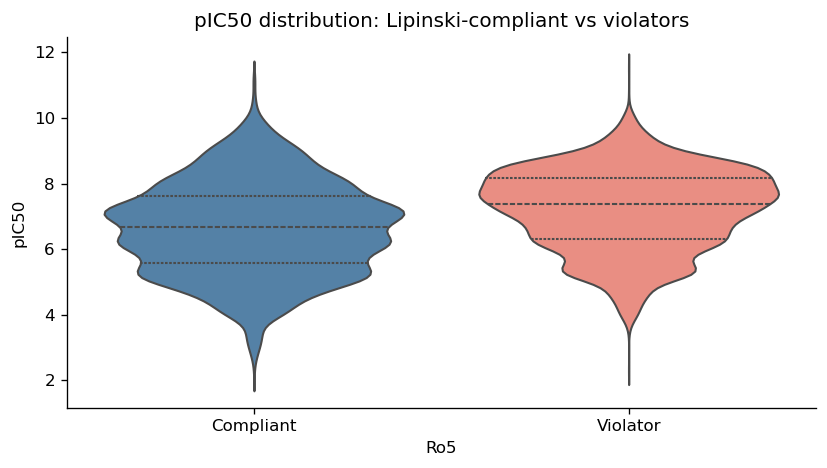

In [58]:
rules = {
    'MW ≤ 500':  df_full['MW']  <= 500,
    'LogP ≤ 5':  df_full['LogP'] <= 5,
    'HBD ≤ 5':   df_full['HBD']  <= 5,
    'HBA ≤ 10':  df_full['HBA']  <= 10,
}
all_pass = pd.concat(rules.values(), axis=1).all(axis=1)

print(f"{'Rule':<15} {'Pass':>6}  {'%':>6}")
print("-" * 30)
for rule, mask in rules.items():
    n = mask.sum()
    print(f"{rule:<15} {n:>6}  {n/len(df_full)*100:>5.1f}%")
print("-" * 30)
n = all_pass.sum()
print(f"{'All 4 rules':<15} {n:>6}  {n/len(df_full)*100:>5.1f}%")

# violin: Ro5-compliant vs violators, split by pIC50
df_full['Ro5'] = all_pass.map({True: 'Compliant', False: 'Violator'})
fig, ax = plt.subplots(figsize=(7, 4))
sns.violinplot(data=df_full, x='Ro5', y='pIC50', palette=['steelblue', 'salmon'],
               inner='quartile', ax=ax)
ax.set_title('pIC50 distribution: Lipinski-compliant vs violators')
plt.tight_layout()
plt.show()

## 6. Chemical space — UMAP of Morgan fingerprints

Morgan fingerprints (ECFP4, radius=2, 2048 bits) compressed to 2D with UMAP using Jaccard distance.  
Colour = pIC50. Hover shows ChEMBL ID, pIC50, MW, LogP, Lipinski Ro5 status, Murcko scaffold, and renders the 2D structure live — reveals whether potent compounds are chemically diverse, Ro5-compliant, or concentrated in a few scaffolds.

In [59]:
def get_murcko(smiles: str) -> str | None:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    scaf = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaf)

df_full['scaffold'] = df_full['smiles'].apply(get_murcko)


In [60]:
fps, valid_idx = [], []
for i, smi in enumerate(df_full['smiles']):
    mol = Chem.MolFromSmiles(smi)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
        arr = np.zeros(2048, dtype=np.uint8)
        DataStructs.ConvertToNumpyArray(fp, arr)
        fps.append(arr)
        valid_idx.append(i)

X = np.array(fps)
print(f"Fingerprints ready: {X.shape}  (n_molecules × bits)")

[23:35:46] DEPRECATION WARNING: please use MorganGenerator
[23:35:46] DEPRECATION WARNING: please use MorganGenerator
[23:35:46] DEPRECATION WARNING: please use MorganGenerator
[23:35:46] DEPRECATION WARNING: please use MorganGenerator
[23:35:46] DEPRECATION WARNING: please use MorganGenerator
[23:35:46] DEPRECATION WARNING: please use MorganGenerator
[23:35:46] DEPRECATION WARNING: please use MorganGenerator
[23:35:46] DEPRECATION WARNING: please use MorganGenerator
[23:35:46] DEPRECATION WARNING: please use MorganGenerator
[23:35:46] DEPRECATION WARNING: please use MorganGenerator
[23:35:46] DEPRECATION WARNING: please use MorganGenerator
[23:35:46] DEPRECATION WARNING: please use MorganGenerator
[23:35:46] DEPRECATION WARNING: please use MorganGenerator
[23:35:46] DEPRECATION WARNING: please use MorganGenerator
[23:35:46] DEPRECATION WARNING: please use MorganGenerator
[23:35:46] DEPRECATION WARNING: please use MorganGenerator
[23:35:46] DEPRECATION WARNING: please use MorganGenerat

Fingerprints ready: (10502, 2048)  (n_molecules × bits)


[23:35:49] DEPRECATION WARNING: please use MorganGenerator
[23:35:49] DEPRECATION WARNING: please use MorganGenerator
[23:35:49] DEPRECATION WARNING: please use MorganGenerator
[23:35:49] DEPRECATION WARNING: please use MorganGenerator
[23:35:49] DEPRECATION WARNING: please use MorganGenerator
[23:35:49] DEPRECATION WARNING: please use MorganGenerator
[23:35:49] DEPRECATION WARNING: please use MorganGenerator
[23:35:49] DEPRECATION WARNING: please use MorganGenerator
[23:35:49] DEPRECATION WARNING: please use MorganGenerator
[23:35:49] DEPRECATION WARNING: please use MorganGenerator
[23:35:49] DEPRECATION WARNING: please use MorganGenerator
[23:35:49] DEPRECATION WARNING: please use MorganGenerator
[23:35:49] DEPRECATION WARNING: please use MorganGenerator
[23:35:49] DEPRECATION WARNING: please use MorganGenerator
[23:35:49] DEPRECATION WARNING: please use MorganGenerator
[23:35:49] DEPRECATION WARNING: please use MorganGenerator
[23:35:49] DEPRECATION WARNING: please use MorganGenerat

In [61]:
from umap import UMAP

print("Running UMAP (Jaccard, n_neighbors=30) — takes ~1–2 min for 10k molecules…")
reducer = UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
               metric='jaccard', random_state=42, verbose=False)
embedding = reducer.fit_transform(X)

df_umap = df_full.iloc[valid_idx].copy().reset_index(drop=True)
df_umap['umap_x'] = embedding[:, 0]
df_umap['umap_y'] = embedding[:, 1]
print("Done.")

Running UMAP (Jaccard, n_neighbors=30) — takes ~1–2 min for 10k molecules…
Done.


In [62]:
import base64
from io import BytesIO

import ipywidgets as widgets
import plotly.graph_objects as go
from rdkit.Chem import Draw


def mol_image_png(smiles: str) -> bytes:
    mol = Chem.MolFromSmiles(smiles)
    buf = BytesIO()
    Draw.MolToImage(mol, size=(300, 300)).save(buf, format='PNG')
    return buf.getvalue()


hover_text = (
    'ChEMBL: ' + df_umap['molecule_chembl_id'].astype(str)
    + '<br>pIC50: ' + df_umap['pIC50'].round(2).astype(str)
    + '<br>MW: ' + df_umap['MW'].round(0).astype(str)
    + '   LogP: ' + df_umap['LogP'].round(2).astype(str)
    + '<br>Ro5: ' + df_umap['Ro5'].astype(str)
)

fig = go.FigureWidget(
    data=[go.Scattergl(
        x=df_umap['umap_x'], y=df_umap['umap_y'], mode='markers',
        marker=dict(color=df_umap['pIC50'], colorscale='RdYlGn', size=4,
                    colorbar=dict(title='pIC50'), showscale=True),
        text=hover_text, hoverinfo='text', customdata=df_umap['smiles'],
    )],
    layout=dict(width=780, height=600,
                title='EGFR Chemical Space — ECFP4 UMAP (hover for structure)',
                xaxis_title='UMAP 1', yaxis_title='UMAP 2'),
)

structure_panel = widgets.Image(format='png', width=300, height=300)


def on_hover(trace, points, state):
    if points.point_inds:
        smi = trace.customdata[points.point_inds[0]]
        structure_panel.value = mol_image_png(smi)


fig.data[0].on_hover(on_hover)

# ponytail: align_items='flex-start' stops HBox's default stretch from
# squashing the fixed-size structure image to the plot's full height.
widgets.HBox([fig, structure_panel], layout=widgets.Layout(align_items='flex-start'))
# ponytail: image rendered lazily per-hover (RDKit Draw call), not pre-embedded —
# embedding ~10k structure thumbnails would bloat the notebook file by ~100MB.


    'data': [{'customdata': array(['C[S+]([O-])c1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccn…

## 7. Scaffold diversity (Murcko)

Murcko scaffolds strip all side chains, leaving the ring system.  
High singleton fraction = chemically diverse dataset → scaffold split will be a meaningful generalization test.

In [63]:
scaffold_counts = df_full['scaffold'].value_counts()
n_total    = df_full['scaffold'].notna().sum()
n_unique   = scaffold_counts.shape[0]
n_singleton = (scaffold_counts == 1).sum()

print(f"Total molecules with scaffolds : {n_total:,}")
print(f"Unique Murcko scaffolds        : {n_unique:,}  ({n_unique/n_total*100:.1f}% diversity)")
print(f"Singleton scaffolds            : {n_singleton:,}  ({n_singleton/n_unique*100:.1f}% of all scaffolds)")
print(f"\nTop 10 most common scaffolds:")
print(scaffold_counts.head(10).to_string())


Total molecules with scaffolds : 10,502
Unique Murcko scaffolds        : 3,854  (36.7% diversity)
Singleton scaffolds            : 2,584  (67.0% of all scaffolds)

Top 10 most common scaffolds:
scaffold
c1ccc(Nc2ncnc3ccccc23)cc1                         594
c1ccc(Nc2ccnc(Nc3ccccc3)n2)cc1                    125
c1ccc(Nc2nccc(-c3c[nH]c4ccccc34)n2)cc1            117
C1=C([C@@H](Nc2ccc3ncccc3c2)c2cccnc2)NNN1C1CC1    105
c1ccccc1                                           98
c1ccc(Nc2ccnc3ccccc23)cc1                          95
c1ccc(CNc2ncnc3[nH]c(-c4ccccc4)cc23)cc1            94
c1ccc(Nc2ncnc3ccncc23)cc1                          71
c1ccc(Nc2ncnc3cnccc23)cc1                          66
c1ccc(-c2n[nH]c3ncncc23)cc1                        65


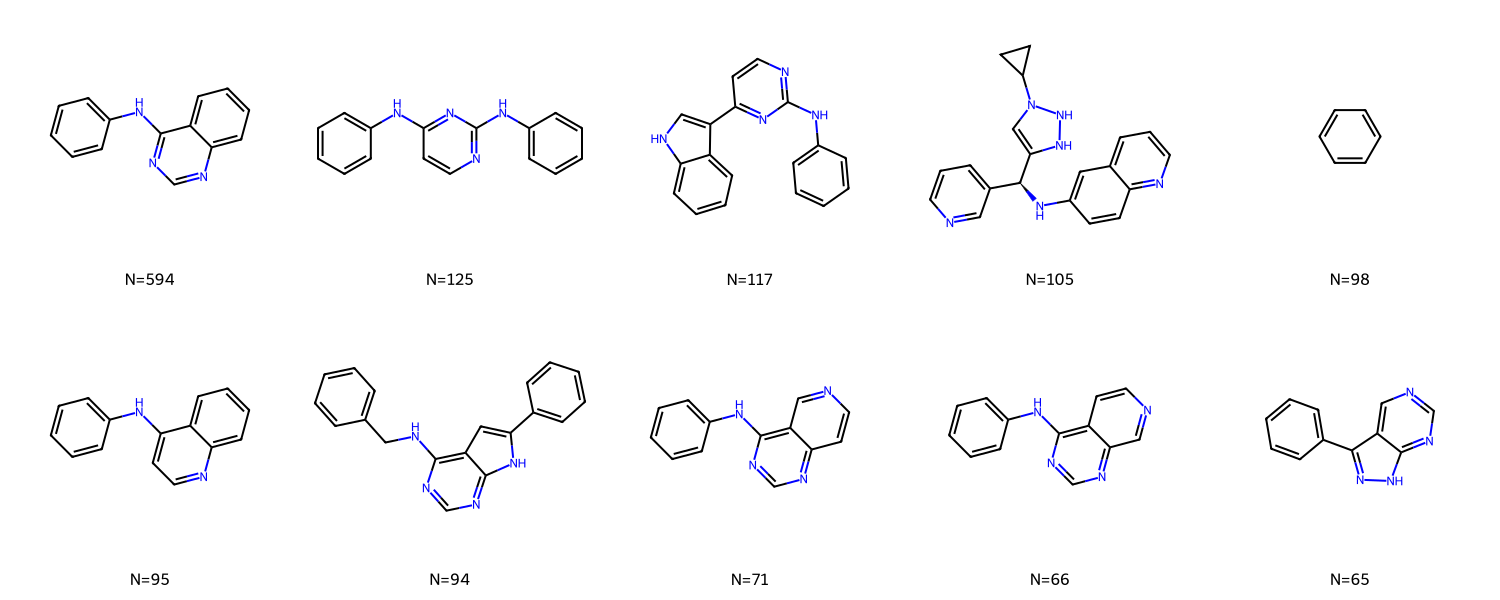

In [64]:
top10_scaffolds = df_full['scaffold'].value_counts().head(10).index

mols = [Chem.MolFromSmiles(s) for s in top10_scaffolds]

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=5,
    subImgSize=(300,300),
    legends=[f"N={df_full['scaffold'].value_counts()[s]}" for s in top10_scaffolds]
)

img

In [65]:
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG

,molecule_chembl_id,Molecule,ScaffoldMol
0,CHEMBL10,,
1,CHEMBL12131,,
2,CHEMBL13485,,
3,CHEMBL13629,,
4,CHEMBL104,,
5,CHEMBL14627,,
6,CHEMBL14699,,
7,CHEMBL14952,,
8,CHEMBL14874,,
9,CHEMBL14932,,

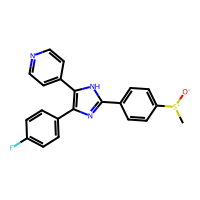
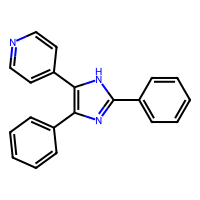
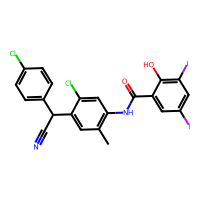
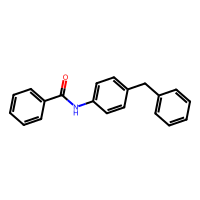
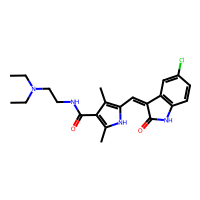
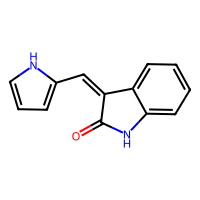
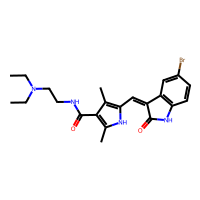
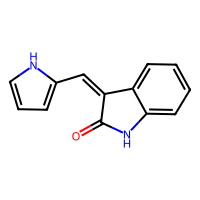
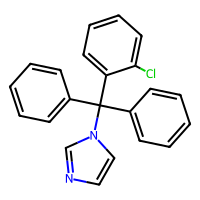
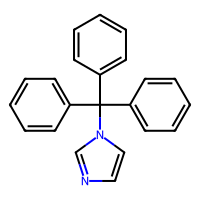
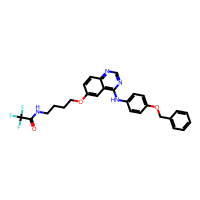
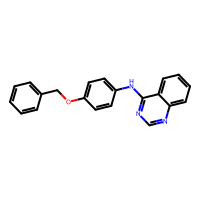
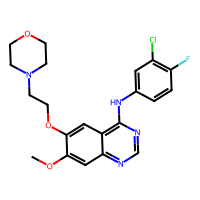
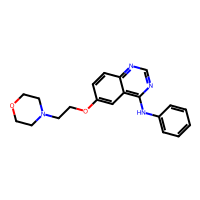
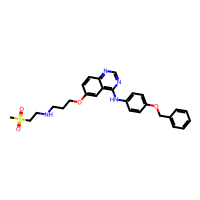
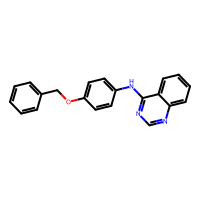
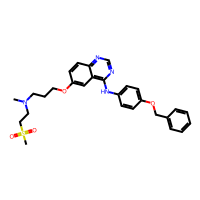
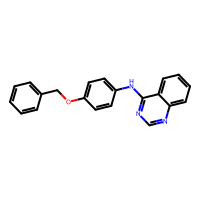
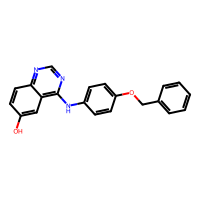
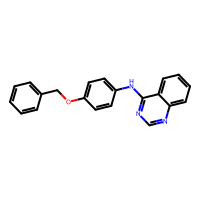
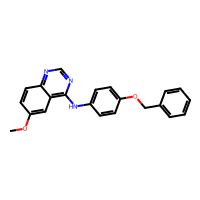
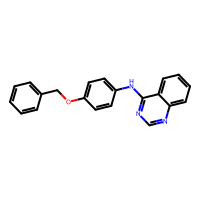
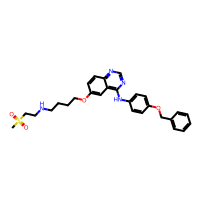
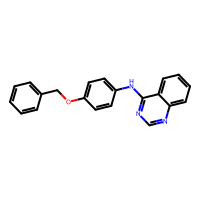
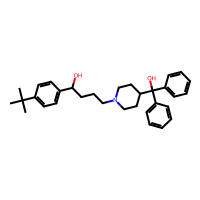
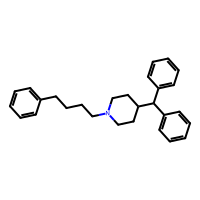
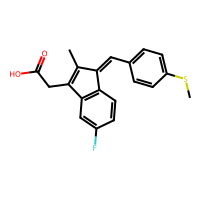
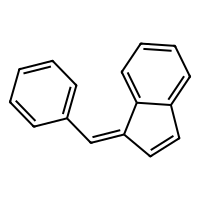
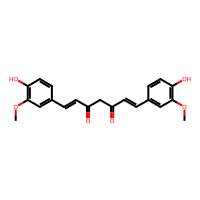
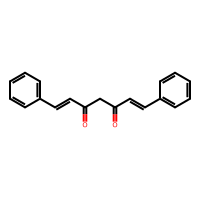
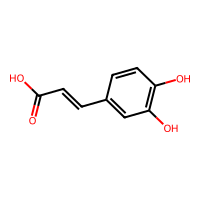
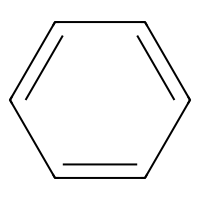
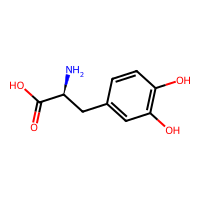
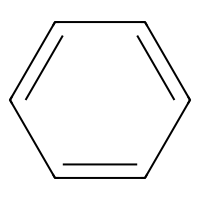
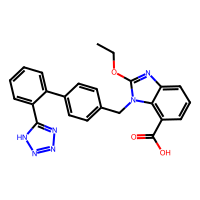
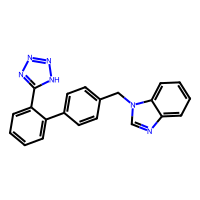
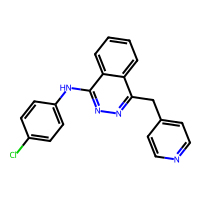
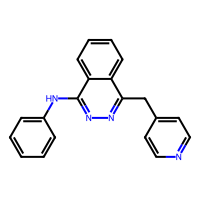
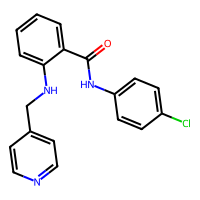
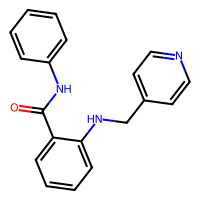

In [66]:
df_show = df_full[['molecule_chembl_id', 'smiles', 'scaffold']].head(20).copy()

PandasTools.AddMoleculeColumnToFrame(
    df_show,
    smilesCol='smiles',
    molCol='Molecule'
)

PandasTools.AddMoleculeColumnToFrame(
    df_show,
    smilesCol='scaffold',
    molCol='ScaffoldMol'
)

df_show[['molecule_chembl_id', 'Molecule', 'ScaffoldMol']]

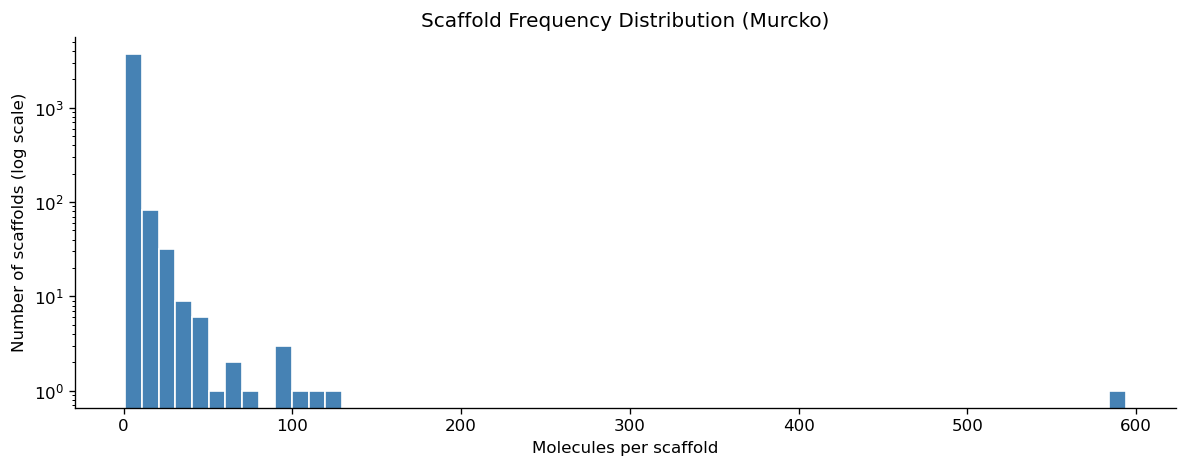

In [67]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(scaffold_counts.values, bins=60, color='steelblue', edgecolor='white', log=True)
ax.set_xlabel('Molecules per scaffold')
ax.set_ylabel('Number of scaffolds (log scale)')
ax.set_title('Scaffold Frequency Distribution (Murcko)')
plt.tight_layout()
plt.show()

## 8. pIC50 vs descriptor correlations

Which descriptors correlate most with potency?  
Strong correlations can inform feature selection and explain model behaviour.

In [68]:
from scipy.stats import spearmanr

print(f"{'Descriptor':<12} {'Spearman ρ':>12}  {'p-value':>10}")
print("-" * 38)
for col in descriptors:
    valid = df_full[['pIC50', col]].dropna()
    rho, pval = spearmanr(valid['pIC50'], valid[col])
    print(f"{col:<12} {rho:>12.4f}  {pval:>10.2e}")

Descriptor     Spearman ρ     p-value
--------------------------------------
MW                 0.3107   8.22e-234
LogP               0.2087   1.00e-103
HBD                0.2089   7.53e-104
HBA                0.3037   6.74e-223
TPSA               0.1393    1.21e-46
RotBonds           0.2640   5.47e-167
Rings              0.2370   4.56e-134
ArRings            0.1519    2.95e-55


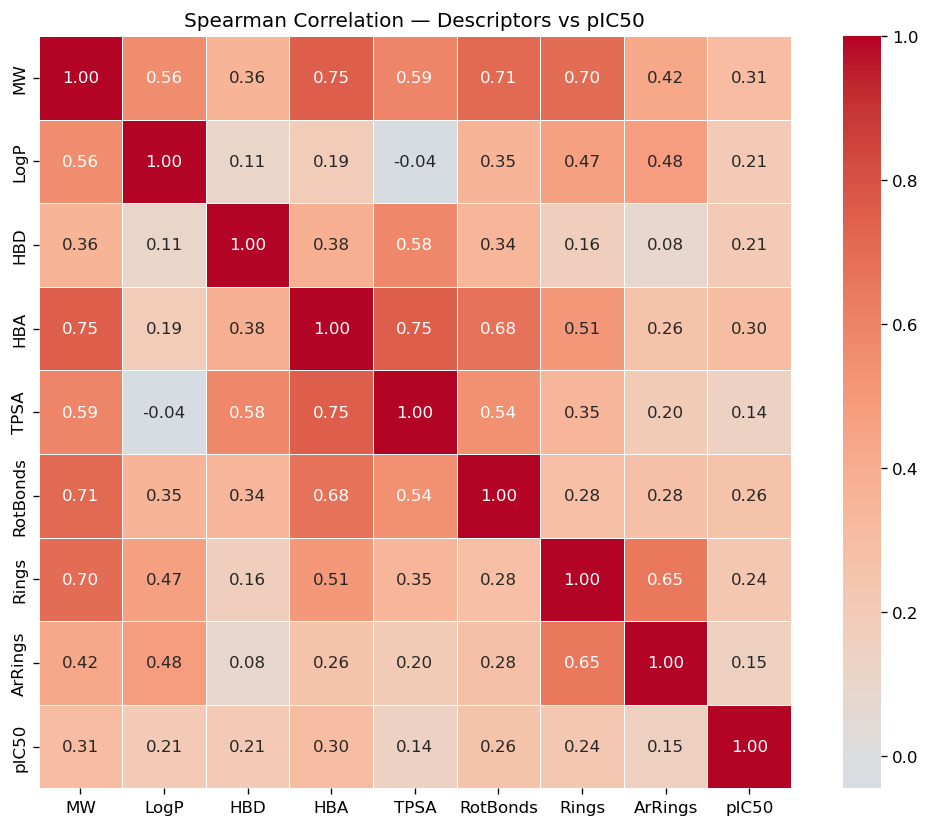

In [69]:
corr_cols = descriptors + ['pIC50']
corr_matrix = df_full[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5, ax=ax
)
ax.set_title('Spearman Correlation — Descriptors vs pIC50')
plt.tight_layout()
plt.show()